<a href="https://colab.research.google.com/github/mennawael05/Water-Stress-Detection-System/blob/main/cnn%2Blstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORT LIBRARIES

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
X = np.load('/content/water_stress_tensors_generate.npy')
y = np.load('/content/water_stress_labels_generate.npy').astype(np.float32)


# DATA UNDERSTANDING

In [ ]:
X = np.load('/content/water_stress_tensors_generate.npy')
y = np.load('/content/water_stress_labels_generate.npy').astype(np.float32)

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")

print(f"Stressed     : {y.sum():.0f}")
print(f"Not-Stressed : {(1-y).sum():.0f}")


X shape : (1000, 5, 4, 4, 7)
y shape : (1000,)
Stressed     : 500
Not-Stressed : 500


# TRAIN / VAL / TEST SPLIT

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"\nTrain : {len(X_train)}")
print(f"Val   : {len(X_val)}")
print(f"Test  : {len(X_test)}")


Train : 700
Val   : 150
Test  : 150


# CNN + LSTM MODEL

In [ ]:

def to_tensor(arr):
    """
    (N, T, H, W, C)
    →
    (N, T, C, H, W)
    """
    t = torch.tensor(arr, dtype=torch.float32)
    return t.permute(0, 1, 4, 2, 3)


Xt_train = to_tensor(X_train)
Xt_val   = to_tensor(X_val)
Xt_test  = to_tensor(X_test)

yt_train = torch.tensor(y_train)
yt_val   = torch.tensor(y_val)
yt_test  = torch.tensor(y_test)




BATCH = 32

train_loader = DataLoader(
    TensorDataset(Xt_train, yt_train),
    batch_size=BATCH,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(Xt_val, yt_val),
    batch_size=BATCH
)

test_loader = DataLoader(
    TensorDataset(Xt_test, yt_test),
    batch_size=BATCH
)




class SpatialCNN(nn.Module):

    def __init__(self, in_channels=7, out_dim=32):

        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(in_channels, 16, kernel_size=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=2, padding=0),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1),

            nn.Flatten(),

            nn.Linear(32, out_dim),
            nn.ReLU(),

            nn.Dropout(0.5)
        )

    def forward(self, x):
        return self.net(x)




class WaterStressCNNLSTM(nn.Module):

    def __init__(
        self,
        in_channels=7,
        cnn_dim=32,
        lstm_hidden=64,
        dropout=0.5
    ):

        super().__init__()

        self.cnn = SpatialCNN(in_channels, cnn_dim)

        self.lstm = nn.LSTM(
            input_size=cnn_dim,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True,
            dropout=0,
            bidirectional=False
        )

        self.classifier = nn.Sequential(

            nn.Linear(lstm_hidden, 32),
            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(32, 1)
        )

    def forward(self, x):

        B, T, C, H, W = x.shape

        cnn_out = torch.stack(
            [self.cnn(x[:, t]) for t in range(T)],
            dim=1
        )

        lstm_out, _ = self.lstm(cnn_out)

        last = lstm_out[:, -1, :]

        logit = self.classifier(last).squeeze(1)

        return logit



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"\nDevice: {device}")




model = WaterStressCNNLSTM().to(device)

total_params = sum(p.numel() for p in model.parameters())

print(f"Parameters: {total_params:,}")



criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-3
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=4,
    factor=0.5
)



EPOCHS = 30

history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}

best_val_loss = float('inf')
best_state = None


patience = 8
counter = 0

print(f"\nTraining for {EPOCHS} epochs...\n")


for epoch in range(1, EPOCHS + 1):


    model.train()

    t_loss = 0
    t_correct = 0
    t_total = 0

    for xb, yb in train_loader:

        xb = xb.to(device)
        yb = yb.to(device)


        noise = torch.randn_like(xb) * 0.01
        xb = xb + noise

        optimizer.zero_grad()

        logits = model(xb)

        loss = criterion(logits, yb)

        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        t_loss += loss.item() * len(yb)

        preds = (torch.sigmoid(logits) > 0.5).float()

        t_correct += (preds == yb).sum().item()

        t_total += len(yb)

    t_loss /= t_total
    t_acc = t_correct / t_total



    model.eval()

    v_loss = 0
    v_correct = 0
    v_total = 0

    with torch.no_grad():

        for xb, yb in val_loader:

            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)

            loss = criterion(logits, yb)

            v_loss += loss.item() * len(yb)

            preds = (torch.sigmoid(logits) > 0.5).float()

            v_correct += (preds == yb).sum().item()

            v_total += len(yb)

    v_loss /= v_total
    v_acc = v_correct / v_total

    scheduler.step(v_loss)

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)

    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)


    if v_loss < best_val_loss:

        best_val_loss = v_loss

        best_state = {
            k: v.cpu().clone()
            for k, v in model.state_dict().items()
        }

        counter = 0

    else:
        counter += 1




    if counter >= patience:

        print(f"\nEarly stopping at epoch {epoch}")

        break



    if epoch % 5 == 0 or epoch == 1:

        print(
            f"Epoch {epoch:3d}/{EPOCHS}  "
            f"Train Loss: {t_loss:.4f}  "
            f"Acc: {t_acc:.3f}  |  "
            f"Val Loss: {v_loss:.4f}  "
            f"Acc: {v_acc:.3f}"
        )




model.load_state_dict(best_state)

model.eval()




all_probs = []
all_labels = []

with torch.no_grad():

    for xb, yb in test_loader:

        xb = xb.to(device)

        probs = torch.sigmoid(model(xb)).cpu()

        all_probs.append(probs)

        all_labels.append(yb)


probs = torch.cat(all_probs).numpy()

labels = torch.cat(all_labels).numpy()

preds = (probs > 0.5).astype(int)



Device: cuda
Parameters: 30,897

Training for 30 epochs...

Epoch   1/30  Train Loss: 0.6940  Acc: 0.500  |  Val Loss: 0.6891  Acc: 0.507
Epoch   5/30  Train Loss: 0.4702  Acc: 0.797  |  Val Loss: 0.4911  Acc: 0.767
Epoch  10/30  Train Loss: 0.3460  Acc: 0.861  |  Val Loss: 0.2549  Acc: 0.927
Epoch  15/30  Train Loss: 0.2413  Acc: 0.907  |  Val Loss: 0.3273  Acc: 0.833
Epoch  20/30  Train Loss: 0.1957  Acc: 0.929  |  Val Loss: 0.1427  Acc: 0.947
Epoch  25/30  Train Loss: 0.1844  Acc: 0.934  |  Val Loss: 0.1384  Acc: 0.940
Epoch  30/30  Train Loss: 0.1299  Acc: 0.961  |  Val Loss: 0.1118  Acc: 0.967


# MODEL EVALUATION


Classification Report:

              precision    recall  f1-score   support

Not Stressed       0.88      0.97      0.92        75
    Stressed       0.97      0.87      0.92        75

    accuracy                           0.92       150
   macro avg       0.92      0.92      0.92       150
weighted avg       0.92      0.92      0.92       150

ROC-AUC: 0.9872

Best Validation Accuracy: 0.9667
Last Training Accuracy:   0.9614
Last Validation Accuracy: 0.9667


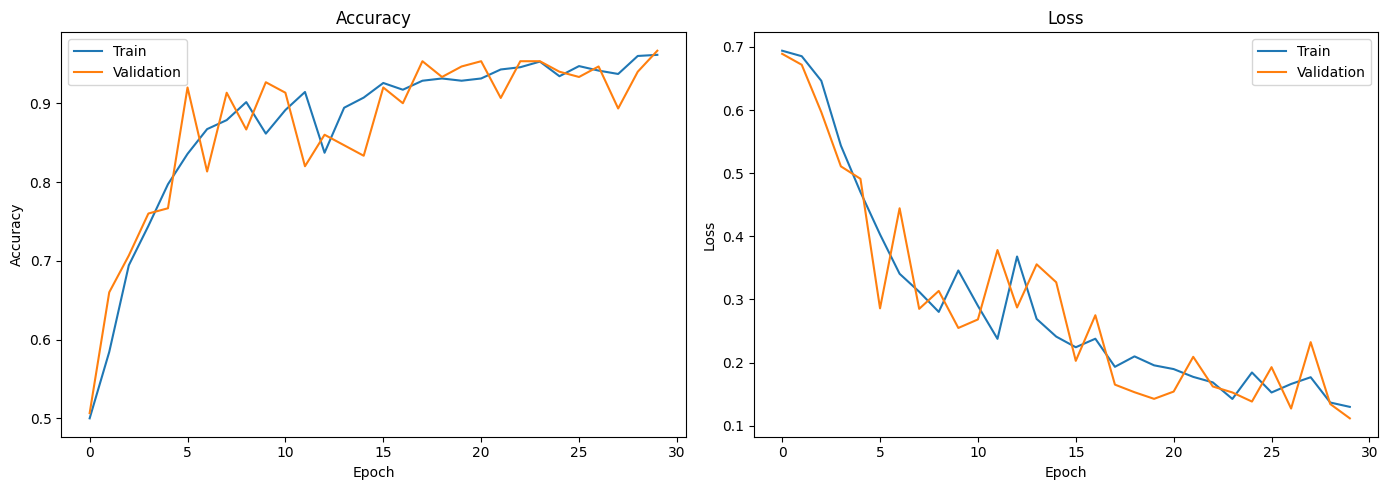

In [ ]:
print("\nClassification Report:\n")

print(
    classification_report(
        labels,
        preds,
        target_names=['Not Stressed', 'Stressed']
    )
)

auc = roc_auc_score(labels, probs)

print(f"ROC-AUC: {auc:.4f}")
print(f"\nBest Validation Accuracy: {max(history['val_acc']):.4f}")
print(f"Last Training Accuracy:   {history['train_acc'][-1]:.4f}")
print(f"Last Validation Accuracy: {history['val_acc'][-1]:.4f}")

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train')
plt.plot(history['val_acc'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()

plt.show()